In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv("fitness_tracker.csv")
data.head()

,Steps,Active_Minutes,Heart_Rate,Sleep_Hours,Calories_Burned
0,5000,30,80,7,220
1,8000,50,85,6,350
2,3000,20,75,8,150
3,12000,70,90,6,500
4,7000,40,82,7,300


In [3]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Steps            174 non-null    int64
 1   Active_Minutes   174 non-null    int64
 2   Heart_Rate       174 non-null    int64
 3   Sleep_Hours      174 non-null    int64
 4   Calories_Burned  174 non-null    int64
dtypes: int64(5)
memory usage: 6.9 KB
None
              Steps  Active_Minutes  Heart_Rate  Sleep_Hours  Calories_Burned
count    174.000000      174.000000  174.000000   174.000000       174.000000
mean    8620.114943       51.689655   85.057471     6.591954       373.275862
std     3660.837579       21.890062    6.040052     0.797499       149.365377
min      900.000000       10.000000   74.000000     2.000000       100.000000
25%     5000.000000       32.000000   80.000000     6.000000       230.000000
50%     8000.000000       50.000000   85.000000     6.000000       360.000000

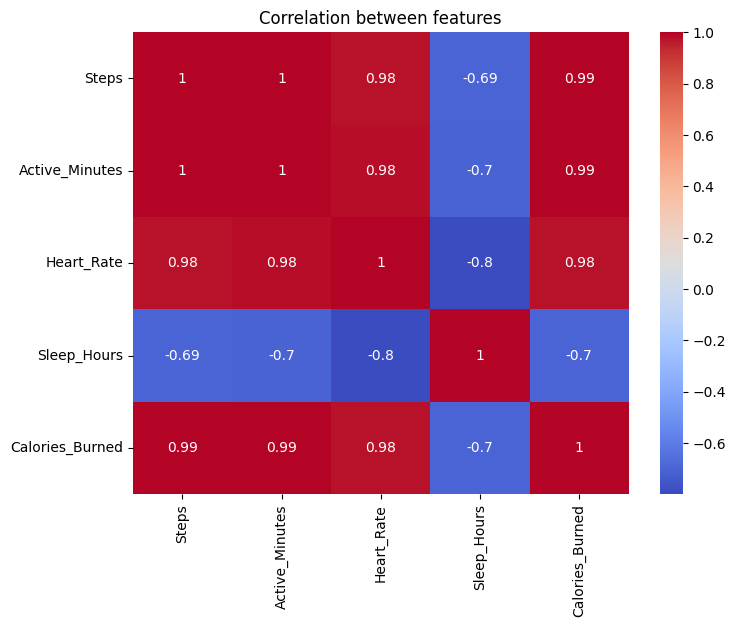

In [4]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between features")
plt.show()

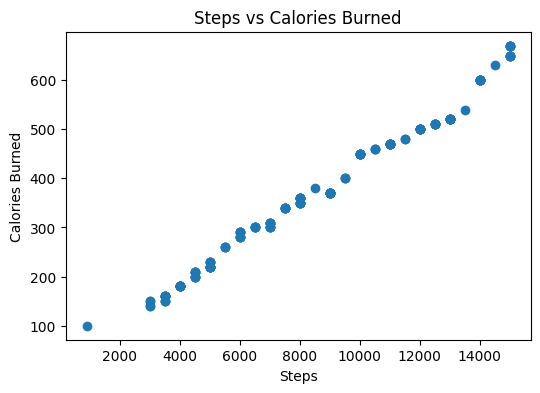

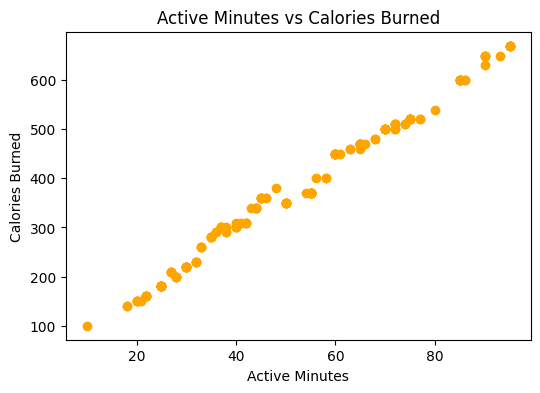

In [5]:
#Scatter plots
plt.figure(figsize=(6,4))
plt.scatter(data['Steps'], data['Calories_Burned'])
plt.xlabel("Steps")
plt.ylabel("Calories Burned")
plt.title("Steps vs Calories Burned")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(data['Active_Minutes'], data['Calories_Burned'], color='orange')
plt.xlabel("Active Minutes")
plt.ylabel("Calories Burned")
plt.title("Active Minutes vs Calories Burned")
plt.show()

In [6]:
# Prepare Features & Target
X = data[['Steps','Active_Minutes','Heart_Rate','Sleep_Hours']]
y = data['Calories_Burned']

In [7]:
# Split Data into Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_pred = model.predict(X_test)

In [10]:
# Evaluate Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 164.08
R^2 Score: 0.99


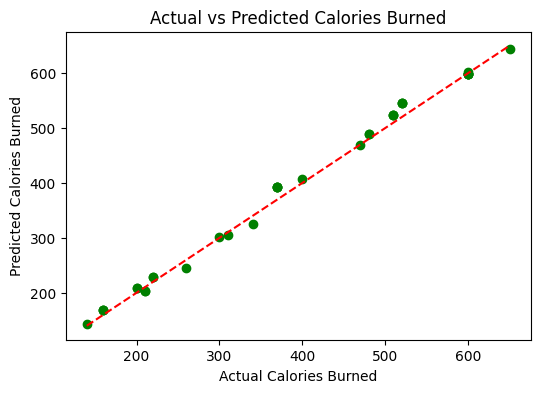

In [11]:
#Visualize Predictions vs Actual
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Actual vs Predicted Calories Burned")
plt.show()

In [13]:
#Q-3 Outlier Detection
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

print("Q1:\n", Q1)
print("\nQ3:\n", Q3)
print("\nIQR:\n", IQR)


Q1:
 Steps              5000.0
Active_Minutes       32.0
Heart_Rate           80.0
Sleep_Hours           6.0
Calories_Burned     230.0
Name: 0.25, dtype: float64

Q3:
 Steps              12000.0
Active_Minutes        70.0
Heart_Rate            90.0
Sleep_Hours            7.0
Calories_Burned      500.0
Name: 0.75, dtype: float64

IQR:
 Steps              7000.0
Active_Minutes       38.0
Heart_Rate           10.0
Sleep_Hours           1.0
Calories_Burned     270.0
dtype: float64


In [14]:
outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))
outlier_counts = outliers.sum()

print("Number of outliers per column:\n", outlier_counts)

Number of outliers per column:
 Steps              0
Active_Minutes     0
Heart_Rate         0
Sleep_Hours        1
Calories_Burned    0
dtype: int64


In [15]:
outlier_data = data[(data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))].dropna(how='all')
outlier_data

,Steps,Active_Minutes,Heart_Rate,Sleep_Hours,Calories_Burned
67,NaN,NaN,NaN,2.0,NaN


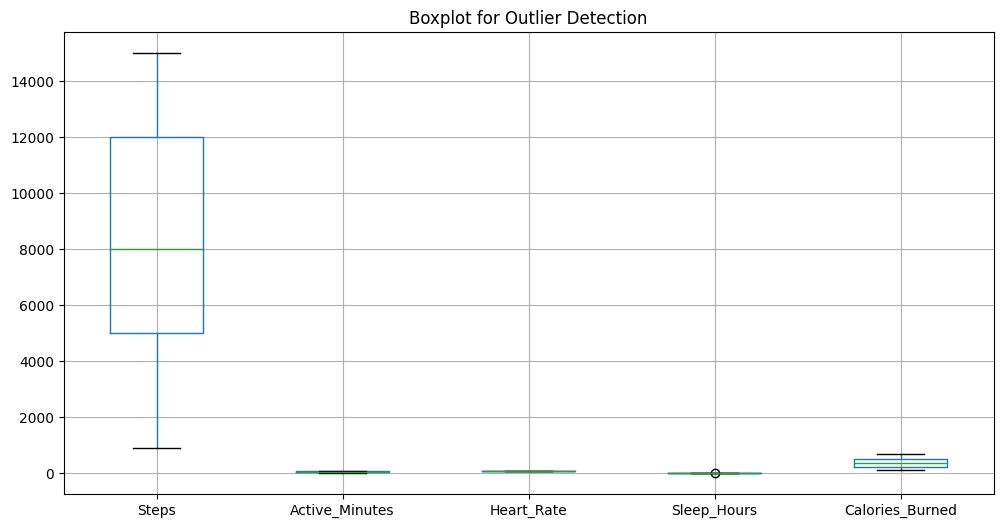

In [16]:
plt.figure(figsize=(12,6))
data.boxplot(column=['Steps', 'Active_Minutes', 'Heart_Rate', 'Sleep_Hours', 'Calories_Burned'])
plt.title("Boxplot for Outlier Detection")
plt.show()

In [18]:
#Q-4 Data Visualization
# Create step bins
bins = [0, 5000, 8000, 10000, 12000, 15000, 16000]
labels = ['0-5k','5k-8k','8k-10k','10k-12k','12k-15k','15k+']
data['Step_Range'] = pd.cut(data['Steps'], bins=bins, labels=labels, include_lowest=True)

# Group by step range
avg_calories = data.groupby('Step_Range')['Calories_Burned'].mean()


C:\Users\Akrit\AppData\Local\Temp\ipykernel_26016\1021702303.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_calories = data.groupby('Step_Range')['Calories_Burned'].mean()


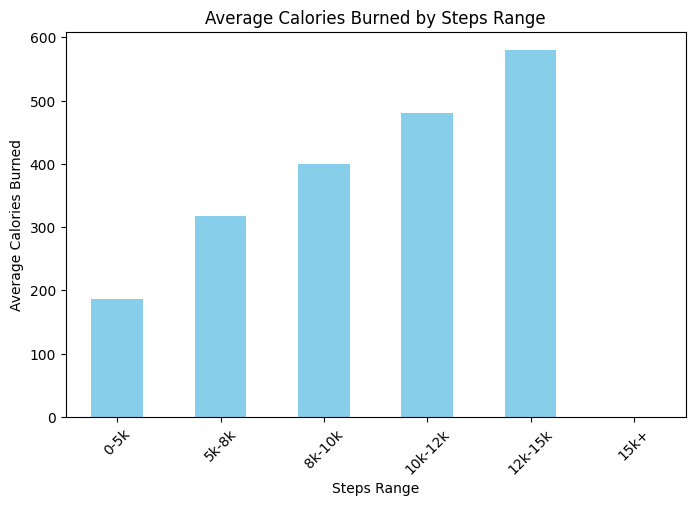

In [19]:
# Plot
plt.figure(figsize=(8,5))
avg_calories.plot(kind='bar', color='skyblue')
plt.title("Average Calories Burned by Steps Range")
plt.xlabel("Steps Range")
plt.ylabel("Average Calories Burned")
plt.xticks(rotation=45)
plt.show()

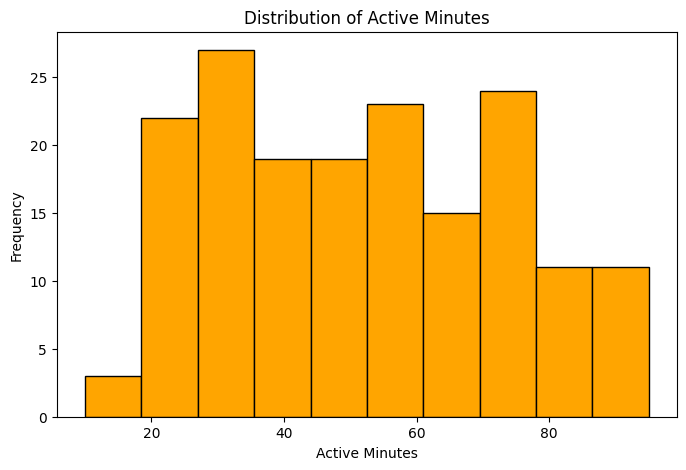

In [20]:
#Histogram
plt.figure(figsize=(8,5))
plt.hist(data['Active_Minutes'], bins=10, color='orange', edgecolor='black')
plt.title("Distribution of Active Minutes")
plt.xlabel("Active Minutes")
plt.ylabel("Frequency")
plt.show()

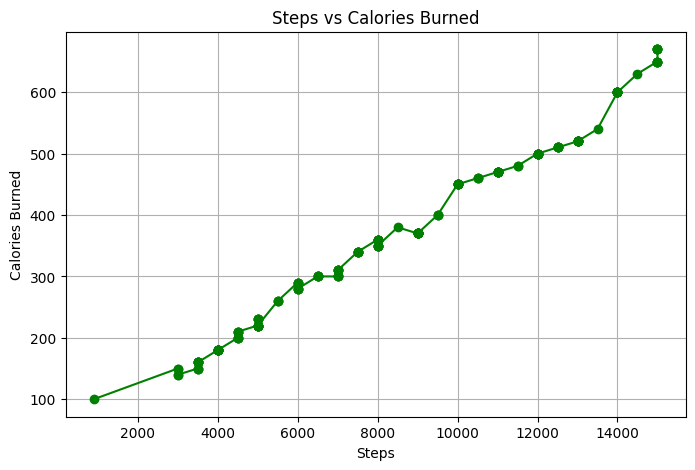

In [21]:
#Line Graph
data_sorted = data.sort_values('Steps')

plt.figure(figsize=(8,5))
plt.plot(data_sorted['Steps'], data_sorted['Calories_Burned'], marker='o', linestyle='-', color='green')
plt.title("Steps vs Calories Burned")
plt.xlabel("Steps")
plt.ylabel("Calories Burned")
plt.grid(True)
plt.show()

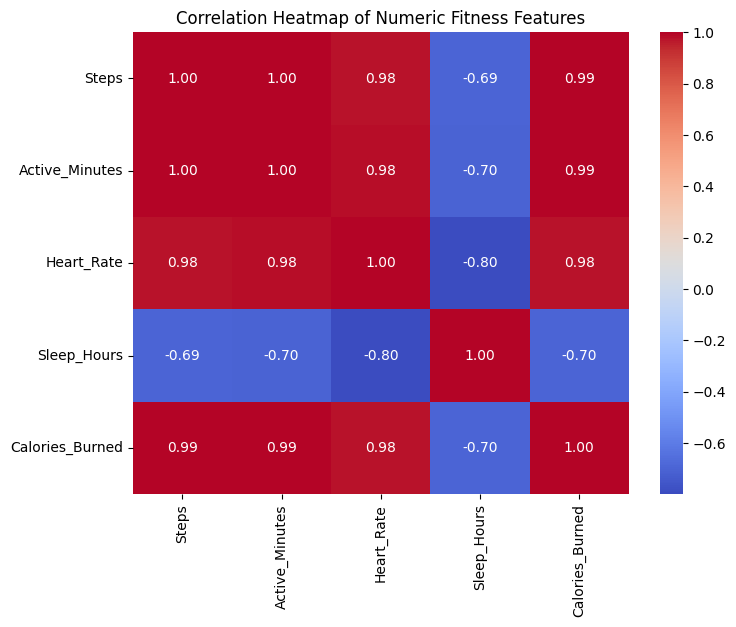

In [23]:
#Correlation Heatmap
# Select only numeric columns
numeric_data = data.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Fitness Features")
plt.show()